# PA Junction Pressure Balance Analysis

In [22]:
from pathlib import Path

JSONL_PATH = Path("../pa_sweep_100_7000_0_05.jsonl")

In [23]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Loads a `.jsonl` file with a record on each line.

records = []
with JSONL_PATH.expanduser().open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

## Junction Pressure Balance Methodology

Compute a metric for the pressure balance about each Junction in the test series. The pressure is computed as the area under the smoothed pressure plot. Two regions are calculated:
1) deceleration pressure - from the start to the end of the deceleration move before the junction
2) acceleration pressure - from the start to the end of the acceleration move after the junction

Pressure changes through the junction because the slowdown in extrudion speed allows the temperature of the filament to increase and thus reduces nozzle pressure. This means the absolute pressure is not comparable between both sides. So we need to find a baseline for each side and create a ratio from that to compare:
1) Find the minimum pressure between the beginning of the deceleration move before the junction and the acceleration move after the junction. This is the shared minimum between both sides
2) For the deceleration side use the force at the beginning of the deceleration as the max force
3) For the acceleration side use the force where acceleration ends as the max force
4) Separately calculate the force delta for each side as max_force - min_force = force_delta
5) Then for each side create a ratio of (area / force_delta) = pressure_ratio

This gives two pressure ratios, which we can then use to calculate the pressure balance as (deceleration_pressure_ratio / acceleration_pressure_ratio) = pressure_balance

The pressure_balance is then plotted for the dataset with `advance` on the x axis and `pressure_balance` on the y axis. The expectation is that pressure balance should swing from positive to negative.

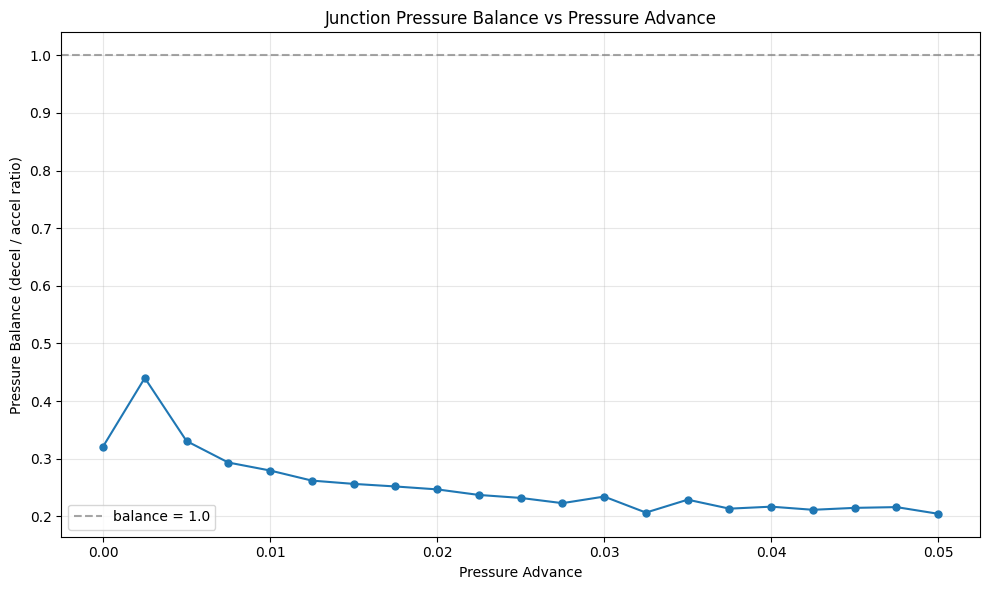

No crossing of balance = 1.0 found


In [30]:
from scipy import signal

SAVGOL_WINDOW = 11
SAVGOL_POLY = 3


def smooth(force):
    return signal.savgol_filter(
        force, window_length=SAVGOL_WINDOW,
        polyorder=SAVGOL_POLY, mode='interp'
    )


def compute_pressure_balance(rec):
    time = np.asarray(rec['time'])
    force = smooth(np.asarray(rec['force']))
    junctions = rec['junctions']
    moves = rec['trapq_moves']
    results = []
    for junc in junctions:
        accel_start = junc['accel_start']
        decel_move = None
        for m in moves:
            end_t = m['print_time'] + m['move_t']
            if m['accel'] < 0 and end_t <= accel_start + 0.001:
                decel_move = m
        accel_move = None
        for m in moves:
            if (m['accel'] > 0
                    and abs(m['print_time'] - accel_start) < 0.001):
                accel_move = m
                break
        if decel_move is None or accel_move is None:
            continue
        PA_SMOOTH_TIME = 0.04
        decel_start_t = decel_move['print_time'] - PA_SMOOTH_TIME
        decel_end_t = decel_start_t + decel_move['move_t']
        accel_start_t = accel_move['print_time']
        accel_end_t = accel_start_t + accel_move['move_t'] + PA_SMOOTH_TIME
        decel_mask = (time >= decel_start_t) & (time <= decel_end_t)
        accel_mask = (time >= accel_start_t) & (time <= accel_end_t)
        if decel_mask.sum() < 3 or accel_mask.sum() < 3:
            continue
        decel_time = time[decel_mask]
        decel_force = force[decel_mask]
        accel_time = time[accel_mask]
        accel_force = force[accel_mask]
        # 1) shared minimum across both regions
        min_force = min(decel_force.min(), accel_force.min())
        # 2) decel max = force at beginning of decel
        decel_max = decel_force[0]
        # 3) accel max = force at end of accel
        accel_max = accel_force[-1]
        # 4) force deltas
        decel_delta = decel_max - min_force
        accel_delta = accel_max - min_force
        if decel_delta < 1e-9 or accel_delta < 1e-9:
            continue
        # area above min_force baseline
        decel_area = np.trapezoid(
            decel_force - min_force, decel_time
        )
        accel_area = np.trapezoid(
            accel_force - min_force, accel_time
        )
        # 5) pressure ratios
        decel_ratio = decel_area / decel_delta
        accel_ratio = accel_area / accel_delta
        pressure_balance = decel_ratio / accel_ratio
        results.append(pressure_balance)
    return np.mean(results) if results else np.nan


advances = []
balances = []
for rec in records:
    pb = compute_pressure_balance(rec)
    advances.append(rec['advance'])
    balances.append(pb)

advances = np.array(advances)
balances = np.array(balances)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(advances, balances, 'o-', markersize=5)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.7,
           label='balance = 1.0')
ax.set_xlabel('Pressure Advance')
ax.set_ylabel('Pressure Balance (decel / accel ratio)')
ax.set_title('Junction Pressure Balance vs Pressure Advance')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

valid = ~np.isnan(balances)
if valid.sum() >= 2:
    adv_valid = advances[valid]
    bal_valid = balances[valid]
    crossings = []
    for i in range(len(bal_valid) - 1):
        if (bal_valid[i] - 1.0) * (bal_valid[i+1] - 1.0) <= 0:
            frac = ((1.0 - bal_valid[i])
                    / (bal_valid[i+1] - bal_valid[i]))
            crossing = (adv_valid[i]
                        + frac * (adv_valid[i+1] - adv_valid[i]))
            crossings.append(crossing)
    if crossings:
        print(f'Balance crosses 1.0 at advance ≈ '
              f'{crossings[0]:.4f}')
    else:
        print('No crossing of balance = 1.0 found')